In [138]:
import pandas as pd
import numpy as np
import random as rnd

import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

Предобработка и подготовка данных

In [139]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [140]:
train_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [141]:
test_df.head(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [142]:
gender_df = pd.read_csv('gender_submission.csv')
gender_df.head(5)

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [143]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


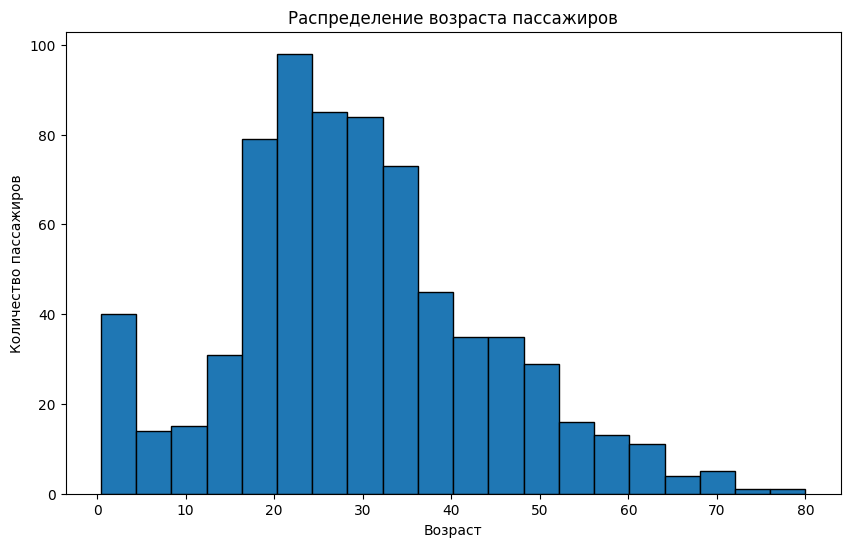

In [144]:
plt.figure(figsize=(10, 6))
plt.hist(train_df['Age'].dropna(), bins=20, edgecolor='black')
plt.title('Распределение возраста пассажиров')
plt.xlabel('Возраст')
plt.ylabel('Количество пассажиров')
plt.show()

Text(0, 0.5, 'Возраст')

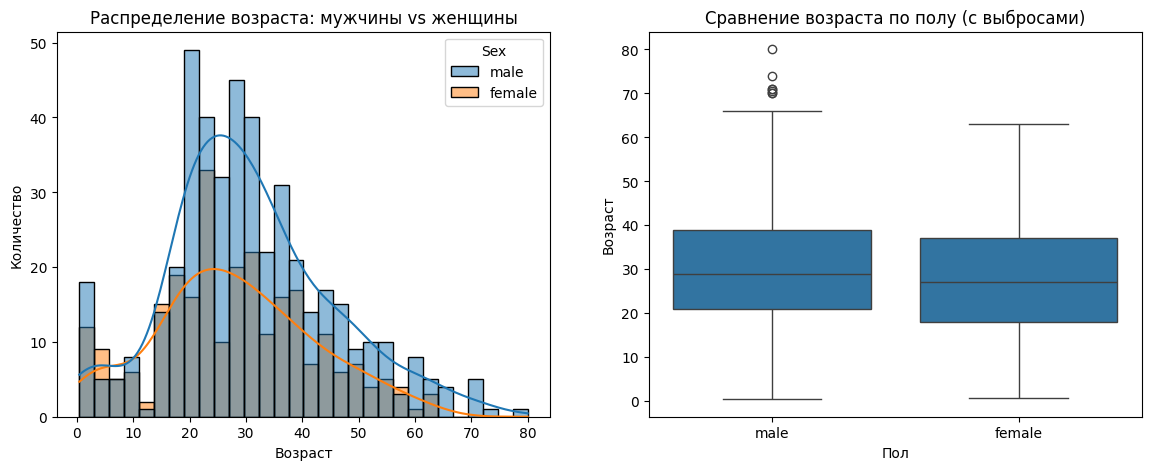

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=train_df, x='Age', hue='Sex', bins=30, kde=True, alpha=0.5, ax=axes[0])
axes[0].set_title('Распределение возраста: мужчины vs женщины')
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Количество')

sns.boxplot(x='Sex', y='Age', data=train_df, ax=axes[1])
axes[1].set_title('Сравнение возраста по полу (с выбросами)')
axes[1].set_xlabel('Пол')
axes[1].set_ylabel('Возраст')

#видим, что есть немного выбросов по возрасту

In [146]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [147]:
y_train = train_df['Survived']
X_train = train_df.drop(columns=['Survived'])

In [149]:
#обрабатываем выбросы и параллельно масштабируем для обучения
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

num_col = X_train.select_dtypes(include=['int64', 'float64']).columns
other_col = X_train.select_dtypes(exclude=['int64', 'float64']).columns

feature_names = (list(num_col) + list(other_col))

transform = ColumnTransformer(
    transformers=[('num', RobustScaler(), num_col)],
    remainder='passthrough'
)

scaler = RobustScaler()

train_df_scal = transform.fit_transform(X_train)
test_df_scal = transform.transform(test_df)

X_train = pd.DataFrame(train_df_scal, columns=feature_names)
test_df = pd.DataFrame(test_df_scal, columns=feature_names)

In [150]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   PassengerId  891 non-null    object
 1   Pclass       891 non-null    object
 2   Age          714 non-null    object
 3   SibSp        891 non-null    object
 4   Parch        891 non-null    object
 5   Fare         891 non-null    object
 6   Name         891 non-null    object
 7   Sex          891 non-null    object
 8   Ticket       891 non-null    object
 9   Cabin        204 non-null    object
 10  Embarked     889 non-null    object
dtypes: object(11)
memory usage: 76.7+ KB


In [151]:
X_train[['PassengerId', 'Pclass', 'SibSp', 'Parch']] = X_train[['PassengerId', 'Pclass', 'SibSp', 'Parch']].astype(int)
X_train[['Age', 'Fare']] = X_train[['Age', 'Fare']].astype(float)

test_df[['PassengerId', 'Pclass', 'SibSp', 'Parch']] = test_df[['PassengerId', 'Pclass', 'SibSp', 'Parch']].astype(int)
test_df[['Age', 'Fare']] = test_df[['Age', 'Fare']].astype(float)

In [152]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Age          332 non-null    float64
 3   SibSp        418 non-null    int64  
 4   Parch        418 non-null    int64  
 5   Fare         417 non-null    float64
 6   Name         418 non-null    object 
 7   Sex          418 non-null    object 
 8   Ticket       418 non-null    object 
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [153]:
X_train.isnull().sum()

PassengerId      0
Pclass           0
Age            177
SibSp            0
Parch            0
Fare             0
Name             0
Sex              0
Ticket           0
Cabin          687
Embarked         2
dtype: int64

In [154]:
X_train.isnull().sum() / len(X_train)

PassengerId    0.000000
Pclass         0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Fare           0.000000
Name           0.000000
Sex            0.000000
Ticket         0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

In [155]:
survival_counts = train_df['Survived'].value_counts()
survival_counts

Survived
0    549
1    342
Name: count, dtype: int64

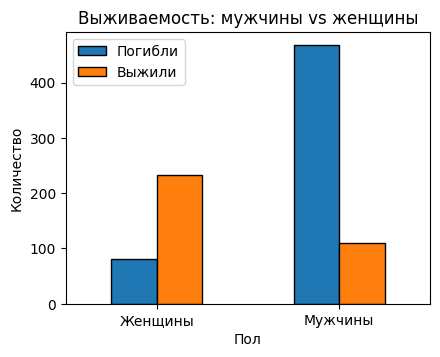

In [156]:
fig = plt.figure(figsize=(16, 12))

ax5 = fig.add_subplot(3, 3, 5)
sex_survival = pd.crosstab(train_df['Sex'], train_df['Survived'])
sex_survival.plot(kind='bar', stacked=False, edgecolor='black', ax=ax5)
ax5.set_title('Выживаемость: мужчины vs женщины')
ax5.set_xlabel('Пол')
ax5.set_ylabel('Количество')
ax5.set_xticklabels(['Женщины', 'Мужчины'], rotation=0)
ax5.legend(['Погибли', 'Выжили'])



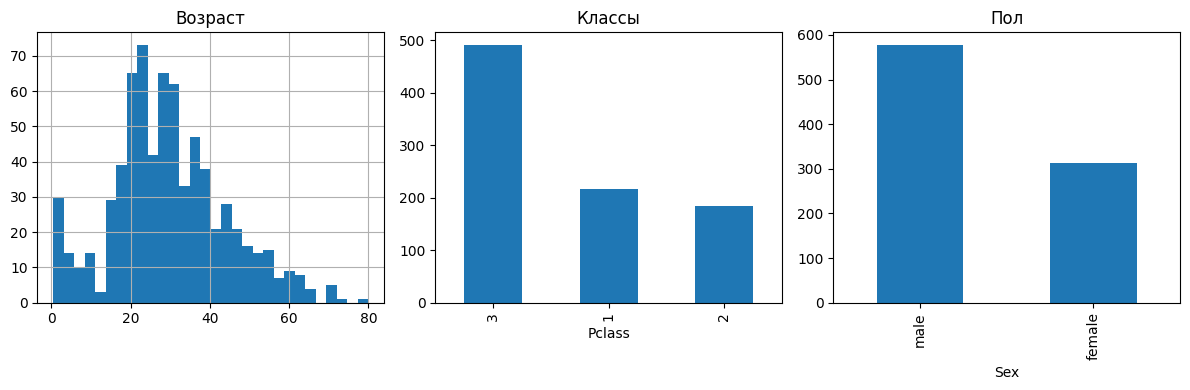

In [157]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
train_df['Age'].hist(bins=30)
plt.title('Возраст')

plt.subplot(1, 3, 2)
train_df['Pclass'].value_counts().plot(kind='bar')
plt.title('Классы')

plt.subplot(1, 3, 3)
train_df['Sex'].value_counts().plot(kind='bar')
plt.title('Пол')

plt.tight_layout()
plt.show()

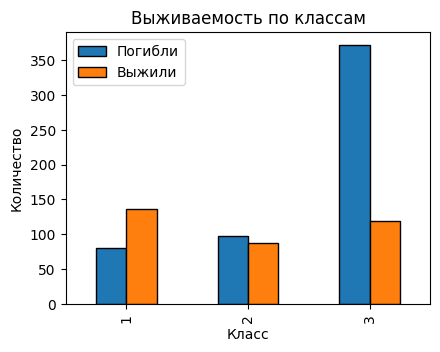

In [158]:
fig = plt.figure(figsize=(16, 12))

ax5 = fig.add_subplot(3, 3, 5)
sex_survival = pd.crosstab(train_df['Pclass'], train_df['Survived'])
sex_survival.plot(kind='bar', stacked=False, edgecolor='black', ax=ax5)
ax5.set_title('Выживаемость по классам')
ax5.set_xlabel('Класс')
ax5.set_ylabel('Количество')
ax5.legend(['Погибли', 'Выжили'])

In [159]:
X_train['Age'] = X_train.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
# заполняем пропуски в данных в зависимости от класса и пола, так как от этих критериев чаще всего зависит возраст, они могут на него влиять
#берем медиану

In [160]:
mode_embarked = X_train['Embarked'].mode()[0]
X_train['Embarked'] = X_train['Embarked'].fillna(mode_embarked)
#заполняем пропуски модой, тк категориальный признак

In [161]:
X_train['Cabin_bin_col'] = X_train['Cabin'].notna().astype(int)
X_train = X_train.drop('Cabin', axis=1)
#очень много пропусков - 77%, поэтому сделает бинарный признак 
#если он не будет давать профита модели, выкинем его

In [162]:
test_df['Cabin_bin_col'] = test_df['Cabin'].notna().astype(int)
test_df = test_df.drop('Cabin', axis=1)

In [163]:
X_train.nunique().sort_values()

Sex                2
Cabin_bin_col      2
Pclass             3
PassengerId        3
Embarked           3
SibSp              7
Parch              7
Age               89
Fare             248
Ticket           681
Name             891
dtype: int64

In [164]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    891 non-null    int64  
 1   Pclass         891 non-null    int64  
 2   Age            891 non-null    float64
 3   SibSp          891 non-null    int64  
 4   Parch          891 non-null    int64  
 5   Fare           891 non-null    float64
 6   Name           891 non-null    object 
 7   Sex            891 non-null    object 
 8   Ticket         891 non-null    object 
 9   Embarked       891 non-null    object 
 10  Cabin_bin_col  891 non-null    int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [165]:
# Берем только ЧИСЛОВЫЕ столбцы
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
train_df[numeric_cols].corr()


,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [166]:
X_train[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()

,Pclass,Age,SibSp,Parch,Fare
Pclass,1.000000,-0.413583,0.083081,0.018443,-0.549500
Age,-0.413583,1.000000,-0.249854,-0.175526,0.122692
SibSp,0.083081,-0.249854,1.000000,0.414838,0.159651
Parch,0.018443,-0.175526,0.414838,1.000000,0.216225
Fare,-0.549500,0.122692,0.159651,0.216225,1.000000


In [167]:
X_train['Sex'] = X_train['Sex'].map({'male': 0, 'female': 1})
#тк у нас всего два пола, заменим с помощью обычного label encoding

In [168]:
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})

In [169]:
X_train = pd.get_dummies(X_train, columns=['Embarked'], prefix='Embarked',drop_first=True, dtype=int) 
#embarked_dummies = pd.get_dummies(X_train['Embarked'], prefix='Embarked',drop_first=True, dtype=int)
#X_train = pd.concat([X_train, embarked_dummies], axis=1)
#X_train

In [170]:
test_df = pd.get_dummies(test_df, columns=['Embarked'], prefix='Embarked',drop_first=True, dtype=int) 

In [171]:
X_train.columns

Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Name', 'Sex',
       'Ticket', 'Cabin_bin_col', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [172]:
X_train = X_train.drop(columns=['Name', 'Ticket'])
test_df = test_df.drop(['Name', 'Ticket'], axis=1)


In [173]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    891 non-null    int64  
 1   Pclass         891 non-null    int64  
 2   Age            891 non-null    float64
 3   SibSp          891 non-null    int64  
 4   Parch          891 non-null    int64  
 5   Fare           891 non-null    float64
 6   Sex            891 non-null    int64  
 7   Cabin_bin_col  891 non-null    int64  
 8   Embarked_Q     891 non-null    int64  
 9   Embarked_S     891 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 69.7 KB


In [174]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
       test_size=0.2,
       random_state=42,
       stratify=y_train
)

In [175]:
from sklearn.metrics import make_scorer, mean_squared_error, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

In [176]:
#функция для датафрейма, где будут храниться все лучшие результаты моделей
#на основе этого выберем лучшую модель в финале и построим финальный прогноз
def add_result(results_df, model_name, test_accuracy, train_accuracy, precision, recall, f1, cross_val):
    new_row = pd.DataFrame([[model_name, test_accuracy, train_accuracy, precision, recall, f1, cross_val]], 
              columns=['Model', 'Accuracy_test', 'Accuracy_train', 'Precision', 'Recall', 'F1', 'Cross-val'])
    results_df = pd.concat([results_df, new_row], ignore_index=True)
    return results_df

results = pd.DataFrame(columns=['Model', 'Accuracy_test', 'Accuracy_train', 'Precision', 'Recall', 'F1', 'Cross-val'])

In [177]:
#функция для расчета метрик
def get_model_scores(model, X_train, y_train, X_test, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    accuracy_train = round(accuracy_score(y_train, y_pred_train), 4)
    accuracy_test = round(accuracy_score(y_test, y_pred_test), 4)
    precision = round(precision_score(y_test, y_pred_test, zero_division=0), 4)
    recall = round(recall_score(y_test, y_pred_test, zero_division=0), 4)
    f1 = round(f1_score(y_test, y_pred_test, zero_division=0), 4)
    
    return accuracy_test, accuracy_train, precision, recall, f1

Так как у нас не так много данных, будем тестировать множество параметров, перебирая их, это будет не очень долго с таким количеством данных.
Если бы это была реальная ситуация, можно было бы пойти иначе:
- мы бы взяли по 2-3 примера каждого параметра и смотрели бы, какой параметр ближе для улучшения результата. После этого перебирали бы параметры вокруг выбранного лучшего примера.
- или можно было бы воспользоваться RandomizedSearchCV для быстрого первичного подбора, а затем уже тоже вручную углубляться в улучшение метрик

После рассмотрения параметров на разных моделях вощьмем одну из лучших по метрикам, посмотрим детальнее, попробуем оптимизировать и построим финальные прогноз на этой модели

In [178]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV


In [ ]:
#уже был robustscaler, поэтому нет смысла в стандартизации
#scaler = StandardScaler()
#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=500, penalty='l2', C=0.1, random_state=42 ) 

cross_val = round(np.mean(cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')), 4)

model.fit(X_train, y_train)

accuracy_test, accuracy_train, precision, recall, f1 = get_model_scores(model, X_train, y_train, X_test, y_test)

results = add_result(results, model, accuracy_test, accuracy_train, precision, recall, f1, cross_val) 
results

c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

,Model,Accuracy_test,Accuracy_train,Precision,Recall,F1,Cross-val
0,"LogisticRegression(C=0.1, max_iter=500, penalt...",0.7933,0.8104,0.7963,0.6232,0.6992,0.8021


In [ ]:
best_accuracy = 0
best_params = None
best_model_obj = None
best_scores = {}

n_neighbors_list = [3, 5, 10]
weights_list = ['uniform', 'distance']
metrics_list = ['euclidean', 'manhattan']

for n in n_neighbors_list:
    for weights in weights_list:
        for metric in metrics_list:
            model = KNeighborsClassifier(
                n_neighbors=n,
                weights=weights,
                metric=metric
            )

            cross_val = round(np.mean(cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')), 4)

            model.fit(X_train, y_train)

            accuracy_test, accuracy_train, precision, recall, f1 = get_model_scores(model, X_train, y_train, X_test, y_test)

            if accuracy_test > best_accuracy and (accuracy_train - accuracy_test) <=0.1:
                best_accuracy = accuracy_test
                best_params = {'n_neighbors': n, 'weights': weights, 'metric': metric}
                best_model_obj = model
                best_scores = {
                    'Accuracy_train': accuracy_train,
                    'Precision': precision,
                    'Recall': recall,
                    'f1': f1,
                    'Cross-val': cross_val
                }
                model_name = f'KNN_n={best_params['n_neighbors']}_w={best_params['weights']}_m={best_params['metric']}'

            print(f'n_neighbors = {n}, weights = {weights}, metric = {metric}')
            print(f'CV Accuracy: {cross_val}')
            print(f'Accuracy_test: {best_accuracy}, Accuracy_train: {accuracy_train}, Precision: {precision}, Recall: {recall}, F1: {f1}\n')

results = add_result(results, model_name, best_accuracy, best_scores['Accuracy_train'], best_scores['Precision'], best_scores['Recall'], best_scores['f1'], best_scores['Cross-val']) 
results


n_neighbors = 3, weights = uniform, metric = euclidean
CV Accuracy: 0.8034
Accuracy_test: 0.7821, Accuracy_train: 0.8638, Precision: 0.7206, Recall: 0.7101, F1: 0.7153

n_neighbors = 3, weights = uniform, metric = manhattan
CV Accuracy: 0.7936
Accuracy_test: 0.7821, Accuracy_train: 0.8694, Precision: 0.6812, Recall: 0.6812, F1: 0.6812

n_neighbors = 3, weights = distance, metric = euclidean
CV Accuracy: 0.7796
Accuracy_test: 0.7821, Accuracy_train: 0.986, Precision: 0.7324, Recall: 0.7536, F1: 0.7429

n_neighbors = 3, weights = distance, metric = manhattan
CV Accuracy: 0.7698
Accuracy_test: 0.7821, Accuracy_train: 0.986, Precision: 0.6944, Recall: 0.7246, F1: 0.7092

n_neighbors = 5, weights = uniform, metric = euclidean
CV Accuracy: 0.8175
Accuracy_test: 0.7821, Accuracy_train: 0.8469, Precision: 0.6818, Recall: 0.6522, F1: 0.6667

n_neighbors = 5, weights = uniform, metric = manhattan
CV Accuracy: 0.8133
Accuracy_test: 0.7821, Accuracy_train: 0.8511, Precision: 0.6912, Recall: 0.6812

,Model,Accuracy_test,Accuracy_train,Precision,Recall,F1,Cross-val
0,"LogisticRegression(C=0.1, max_iter=500, penalt...",0.7933,0.8104,0.7963,0.6232,0.6992,0.8021
1,KNN_n=3_w=uniform_m=euclidean,0.7821,0.8638,0.7206,0.7101,0.7153,0.8034


In [ ]:
depth_list = [3, 5, 7, 10, None]
min_samples_split_list = [2, 5, 10]
min_samples_leaf_list = [1, 2, 4]

best_accuracy = 0
best_params = {}
best_model_obj = None
best_scores = {}

for depth in depth_list:
    for min_split in min_samples_split_list:
        for min_leaf in min_samples_leaf_list:
            model = DecisionTreeClassifier(
                max_depth=depth,
                min_samples_split=min_split,
                min_samples_leaf=min_leaf,
                criterion='gini',  
                random_state=42,
                ccp_alpha = 0.008
            )
            
            cross_val = round(np.mean(cross_val_score(model, X_train, y_train, 
                                        cv=5, 
                                        scoring='accuracy')), 4)
            
            model.fit(X_train, y_train)
            
            accuracy_test, accuracy_train, precision, recall, f1 = get_model_scores(model, X_train, y_train, X_test, y_test)
            
            print(f'depth={depth}, min_split={min_split}, min_leaf={min_leaf}')
            print(f'Accuracy_test: {accuracy_test}, Accuracy_train: {accuracy_train}, Precision: {precision}, Recall: {recall}, F1: {f1}, Cross_val: {cross_val}')

            if accuracy_test > best_accuracy and (accuracy_train - accuracy_test) <=0.1:
                best_accuracy = accuracy_test
                best_params = {
                    'max_depth': depth,
                    'min_samples_split': min_split,
                    'min_samples_leaf': min_leaf
                }
                best_model_obj = model
                best_scores = {
                    'Accuracy_train': accuracy_train,
                    'Precision': precision,
                    'Recall': recall,
                    'f1': f1,
                    'Cross-val': cross_val
                }

                best_model = f"DecisionTreeClassifier_depth={best_params['max_depth']}_split={best_params['min_samples_split']}_leaf={best_params['min_samples_leaf']}"

results = add_result(results, best_model, best_accuracy, best_scores['Accuracy_train'], best_scores['Precision'], best_scores['Recall'], best_scores['f1'], best_scores['Cross-val']) 
results


depth=3, min_split=2, min_leaf=1
Accuracy_test: 0.7765, Accuracy_train: 0.8315, Precision: 0.8085, Recall: 0.5507, F1: 0.6552, Cross_val: 0.8063
depth=3, min_split=2, min_leaf=2
Accuracy_test: 0.7765, Accuracy_train: 0.8315, Precision: 0.8085, Recall: 0.5507, F1: 0.6552, Cross_val: 0.8063
depth=3, min_split=2, min_leaf=4
Accuracy_test: 0.7765, Accuracy_train: 0.8315, Precision: 0.8085, Recall: 0.5507, F1: 0.6552, Cross_val: 0.8063
depth=3, min_split=5, min_leaf=1
Accuracy_test: 0.7765, Accuracy_train: 0.8315, Precision: 0.8085, Recall: 0.5507, F1: 0.6552, Cross_val: 0.8063
depth=3, min_split=5, min_leaf=2
Accuracy_test: 0.7765, Accuracy_train: 0.8315, Precision: 0.8085, Recall: 0.5507, F1: 0.6552, Cross_val: 0.8063
depth=3, min_split=5, min_leaf=4
Accuracy_test: 0.7765, Accuracy_train: 0.8315, Precision: 0.8085, Recall: 0.5507, F1: 0.6552, Cross_val: 0.8063
depth=3, min_split=10, min_leaf=1
Accuracy_test: 0.7765, Accuracy_train: 0.8315, Precision: 0.8085, Recall: 0.5507, F1: 0.6552, Cr

,Model,Accuracy_test,Accuracy_train,Precision,Recall,F1,Cross-val
0,"LogisticRegression(C=0.1, max_iter=500, penalt...",0.7933,0.8104,0.7963,0.6232,0.6992,0.8021
1,KNN_n=3_w=uniform_m=euclidean,0.7821,0.8638,0.7206,0.7101,0.7153,0.8034
2,DecisionTreeClassifier_depth=3_split=2_leaf=1,0.7765,0.8315,0.8085,0.5507,0.6552,0.8063


In [ ]:
n_estimators_list = [50, 100, 200]         
max_depth_list = [5, 10, 15, None]      
min_samples_split_list = [2, 5, 10]         
min_samples_leaf_list = [1, 2, 4]            
max_features_list = ['sqrt', 'log2', 0.5]    
max_samples_list = [0.7, 0.8, 1.0]           
ccp_alpha_list = [0, 0.001, 0.005]           

best_accuracy = 0
best_params = {}
best_model_obj = None
best_scores = {}

for n_est in n_estimators_list:
    for depth in max_depth_list:
        for min_split in min_samples_split_list:
            for min_leaf in min_samples_leaf_list:
                for max_feat in max_features_list:
                    for max_samp in max_samples_list:
                        for alpha in ccp_alpha_list:
                            
                            model = RandomForestClassifier(
                                n_estimators=n_est,
                                max_depth=depth,
                                min_samples_split=min_split,
                                min_samples_leaf=min_leaf,
                                max_features=max_feat,
                                max_samples=max_samp,
                                ccp_alpha=alpha,
                                bootstrap=True,         
                                random_state=42,
                                n_jobs=-1                
                            )
                            
                            cross_val = round(np.mean(cross_val_score(model, X_train, y_train, 
                                                        cv=5, 
                                                        scoring='accuracy')), 4)
                            
                            model.fit(X_train, y_train)
                            
                            accuracy_test, accuracy_train, precision, recall, f1 = get_model_scores(model, X_train, y_train, X_test, y_test)
                            
                            print(f'n_est={n_est}, depth={depth}, min_split={min_split}, min_leaf={min_leaf}, max_feat={max_feat}, max_samp={max_samp}, alpha={alpha}')
                            print(f'Accuracy_test: {accuracy_test}, Accuracy_train: {accuracy_train}, Precision: {precision}, Recall: {recall}, F1: {f1}, Cross_val: {cross_val}')
                            
                            if accuracy_test > best_accuracy and (accuracy_train - accuracy_test) <=0.1:
                                best_accuracy = accuracy_test
                                best_params = {
                                    'n_estimators': n_est,
                                    'max_depth': depth,
                                    'min_samples_split': min_split,
                                    'min_samples_leaf': min_leaf,
                                    'max_features': max_feat,
                                    'max_samples': max_samp,
                                    'ccp_alpha': alpha
                                }
                                best_model_obj = model
                                best_scores = {
                                    'Precision': precision,
                                    'Recall': recall,
                                    'F1': f1,
                                    'Cross-val': cross_val,
                                    'Train_Accuracy': accuracy_train
                                }
                                
                                best_model = f"RandomForest_n_est={best_params['n_estimators']}_depth={best_params['max_depth']}_split={best_params['min_samples_split']}_leaf={best_params['min_samples_leaf']}_features={best_params['max_features']}_samples={best_params['max_samples']}_alpha={best_params['ccp_alpha']}"

results = add_result(results, best_model, best_accuracy, best_scores['Train_Accuracy'], best_scores['Precision'], best_scores['Recall'], best_scores['F1'], best_scores['Cross-val'])
results
        

n_est=50, depth=5, min_split=2, min_leaf=1, max_feat=sqrt, max_samp=0.7, alpha=0
Accuracy_test: 0.7877, Accuracy_train: 0.8624, Precision: 0.7627, Recall: 0.6522, F1: 0.7031, Cross_val: 0.8217
n_est=50, depth=5, min_split=2, min_leaf=1, max_feat=sqrt, max_samp=0.7, alpha=0.001
Accuracy_test: 0.7877, Accuracy_train: 0.8638, Precision: 0.7627, Recall: 0.6522, F1: 0.7031, Cross_val: 0.8189
n_est=50, depth=5, min_split=2, min_leaf=1, max_feat=sqrt, max_samp=0.7, alpha=0.005
Accuracy_test: 0.7821, Accuracy_train: 0.8525, Precision: 0.7586, Recall: 0.6377, F1: 0.6929, Cross_val: 0.8217
n_est=50, depth=5, min_split=2, min_leaf=1, max_feat=sqrt, max_samp=0.8, alpha=0
Accuracy_test: 0.7765, Accuracy_train: 0.8694, Precision: 0.7544, Recall: 0.6232, F1: 0.6825, Cross_val: 0.8189
n_est=50, depth=5, min_split=2, min_leaf=1, max_feat=sqrt, max_samp=0.8, alpha=0.001
Accuracy_test: 0.7709, Accuracy_train: 0.8722, Precision: 0.7414, Recall: 0.6232, F1: 0.6772, Cross_val: 0.8189
n_est=50, depth=5, min_

c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\k

n_est=100, depth=5, min_split=10, min_leaf=1, max_feat=log2, max_samp=1.0, alpha=0.001
Accuracy_test: 0.8045, Accuracy_train: 0.8708, Precision: 0.8148, Recall: 0.6377, F1: 0.7154, Cross_val: 0.8217
n_est=100, depth=5, min_split=10, min_leaf=1, max_feat=log2, max_samp=1.0, alpha=0.005
Accuracy_test: 0.7933, Accuracy_train: 0.8596, Precision: 0.8077, Recall: 0.6087, F1: 0.6942, Cross_val: 0.8161
n_est=100, depth=5, min_split=10, min_leaf=1, max_feat=0.5, max_samp=0.7, alpha=0
Accuracy_test: 0.7989, Accuracy_train: 0.8638, Precision: 0.8, Recall: 0.6377, F1: 0.7097, Cross_val: 0.8161
n_est=100, depth=5, min_split=10, min_leaf=1, max_feat=0.5, max_samp=0.7, alpha=0.001
Accuracy_test: 0.7989, Accuracy_train: 0.8624, Precision: 0.8, Recall: 0.6377, F1: 0.7097, Cross_val: 0.8161
n_est=100, depth=5, min_split=10, min_leaf=1, max_feat=0.5, max_samp=0.7, alpha=0.005
Accuracy_test: 0.7933, Accuracy_train: 0.8483, Precision: 0.7963, Recall: 0.6232, F1: 0.6992, Cross_val: 0.8147
n_est=100, depth=5

c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\kate1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\k

n_est=100, depth=5, min_split=10, min_leaf=2, max_feat=log2, max_samp=0.7, alpha=0.005
Accuracy_test: 0.7933, Accuracy_train: 0.8567, Precision: 0.8077, Recall: 0.6087, F1: 0.6942, Cross_val: 0.8217
n_est=100, depth=5, min_split=10, min_leaf=2, max_feat=log2, max_samp=0.8, alpha=0
Accuracy_test: 0.7765, Accuracy_train: 0.8666, Precision: 0.7458, Recall: 0.6377, F1: 0.6875, Cross_val: 0.8147
n_est=100, depth=5, min_split=10, min_leaf=2, max_feat=log2, max_samp=0.8, alpha=0.001
Accuracy_test: 0.7821, Accuracy_train: 0.8638, Precision: 0.7586, Recall: 0.6377, F1: 0.6929, Cross_val: 0.8133
n_est=100, depth=5, min_split=10, min_leaf=2, max_feat=log2, max_samp=0.8, alpha=0.005
Accuracy_test: 0.7989, Accuracy_train: 0.8596, Precision: 0.8113, Recall: 0.6232, F1: 0.7049, Cross_val: 0.8105
n_est=100, depth=5, min_split=10, min_leaf=2, max_feat=log2, max_samp=1.0, alpha=0
Accuracy_test: 0.7765, Accuracy_train: 0.8666, Precision: 0.7458, Recall: 0.6377, F1: 0.6875, Cross_val: 0.8217
n_est=100, de

,Model,Accuracy_test,Accuracy_train,Precision,Recall,F1,Cross-val
0,"LogisticRegression(C=0.1, max_iter=500, penalt...",0.7933,0.8104,0.7963,0.6232,0.6992,0.8021
1,KNN_n=3_w=uniform_m=euclidean,0.7821,0.8638,0.7206,0.7101,0.7153,0.8034
2,DecisionTreeClassifier_depth=3_split=2_leaf=1,0.7765,0.8315,0.8085,0.5507,0.6552,0.8063
3,RandomForest_n_est=50_depth=10_split=10_leaf=4...,0.8268,0.8567,0.8800,0.6377,0.7395,0.8091


In [ ]:
depth_list = [3, 4, 6, 8]                  
learning_rate_list = [0.01, 0.05, 0.1]       
iterations_list = [100, 200, 500]           
l2_leaf_reg_list = [1, 3, 5]                
bagging_temperature_list = [0, 0.5, 1]       
border_count_list = [32, 64, 128]          

best_accuracy = 0
best_params = {}
best_model_obj = None
best_scores = {}

for depth in depth_list:
    for lr in learning_rate_list:
        for iters in iterations_list:
            for l2_reg in l2_leaf_reg_list:
                for bagging_temp in bagging_temperature_list:
                    for border_cnt in border_count_list:
                        
                        model = CatBoostClassifier(
                            depth=depth,
                            learning_rate=lr,
                            iterations=iters,
                            l2_leaf_reg=l2_reg,
                            bagging_temperature=bagging_temp,
                            border_count=border_cnt,
                            verbose=0,                   
                            random_seed=42,
                            thread_count=-1        
                        )
                        
                        cross_val = round(np.mean(cross_val_score(model, X_train, y_train, 
                                                    cv=5, 
                                                    scoring='accuracy')), 4)
                        
                        model.fit(X_train, y_train, verbose=False)
                        
                        accuracy_test, accuracy_train, precision, recall, f1 = get_model_scores(model, X_train, y_train, X_test, y_test)
                        
                        print(f'depth={depth}, lr={lr}, iters={iters}, l2_reg={l2_reg}, bagging_temp={bagging_temp}, border_cnt={border_cnt}')
                        print(f'Accuracy_test: {accuracy_test}, Accuracy_train: {accuracy_train}, Precision: {precision}, Recall: {recall}, F1: {f1}, Cross_val: {cross_val}')
                        print('-' * 80)
                        
                        if accuracy_test > best_accuracy and (accuracy_train - accuracy_test) <=0.1:
                            best_accuracy = accuracy_test
                            best_params = {
                                'depth': depth,
                                'learning_rate': lr,
                                'iterations': iters,
                                'l2_leaf_reg': l2_reg,
                                'bagging_temperature': bagging_temp,
                                'border_count': border_cnt
                            }
                            best_model_obj = model
                            best_scores = {
                                'Precision': precision,
                                'Recall': recall,
                                'F1': f1,
                                'Cross-val': cross_val,
                                'Train_Accuracy': accuracy_train
                            }
                            
                            best_model = f"CatBoost_depth={best_params['depth']}_lr={best_params['learning_rate']}_iters={best_params['iterations']}_l2={best_params['l2_leaf_reg']}_bagging={best_params['bagging_temperature']}"


results = add_result(results, best_model, best_accuracy, best_scores['Train_Accuracy'], best_scores['Precision'], best_scores['Recall'], best_scores['F1'], best_scores['Cross-val'])
results

depth=3, lr=0.01, iters=100, l2_reg=1, bagging_temp=0, border_cnt=32
Accuracy_test: 0.7989, Accuracy_train: 0.802, Precision: 0.7895, Recall: 0.6522, F1: 0.7143, Cross_val: 0.7964
--------------------------------------------------------------------------------
depth=3, lr=0.01, iters=100, l2_reg=1, bagging_temp=0, border_cnt=64
Accuracy_test: 0.7933, Accuracy_train: 0.802, Precision: 0.7759, Recall: 0.6522, F1: 0.7087, Cross_val: 0.7978
--------------------------------------------------------------------------------
depth=3, lr=0.01, iters=100, l2_reg=1, bagging_temp=0, border_cnt=128
Accuracy_test: 0.7933, Accuracy_train: 0.802, Precision: 0.7759, Recall: 0.6522, F1: 0.7087, Cross_val: 0.795
--------------------------------------------------------------------------------
depth=3, lr=0.01, iters=100, l2_reg=1, bagging_temp=0.5, border_cnt=32
Accuracy_test: 0.7989, Accuracy_train: 0.802, Precision: 0.7895, Recall: 0.6522, F1: 0.7143, Cross_val: 0.7964
-----------------------------------

,Model,Accuracy_test,Accuracy_train,Precision,Recall,F1,Cross-val
0,"LogisticRegression(C=0.1, max_iter=500, penalt...",0.7933,0.8104,0.7963,0.6232,0.6992,0.8021
1,KNN_n=3_w=uniform_m=euclidean,0.7821,0.8638,0.7206,0.7101,0.7153,0.8034
2,DecisionTreeClassifier_depth=3_split=2_leaf=1,0.7765,0.8315,0.8085,0.5507,0.6552,0.8063
3,RandomForest_n_est=50_depth=10_split=10_leaf=4...,0.8268,0.8567,0.8800,0.6377,0.7395,0.8091
4,CatBoost_depth=4_lr=0.1_iters=100_l2=3_bagging=0,0.8268,0.8567,0.8654,0.6522,0.7438,0.8133


In [ ]:
n_estimators_list = [100, 200]           
learning_rate_list = [0.05, 0.1]        
max_depth_list = [5, 7]               
num_leaves_list = [31, 63]              
min_child_samples_list = [10, 20]          
subsample_list = [0.8, 1.0]             
colsample_bytree_list = [0.8, 1.0]      
reg_alpha_list = [0, 0.01]              
reg_lambda_list = [0, 0.01]             

best_accuracy = 0
best_params = {}
best_model_obj = None
best_scores = {}

for n_est in n_estimators_list:
    for lr in learning_rate_list:
        for depth in max_depth_list:
            for num_leaves in num_leaves_list:
                for min_child in min_child_samples_list:
                    for subsample in subsample_list:
                        for colsample in colsample_bytree_list:
                            for reg_alpha in reg_alpha_list:
                                for reg_lambda in reg_lambda_list:
                                    
                                    model = LGBMClassifier(
                                        n_estimators=n_est,
                                        learning_rate=lr,
                                        max_depth=depth,
                                        num_leaves=num_leaves,
                                        min_child_samples=min_child,
                                        subsample=subsample,
                                        colsample_bytree=colsample,
                                        reg_alpha=reg_alpha,
                                        reg_lambda=reg_lambda,
                                        random_state=42,
                                        verbose=-1,
                                        n_jobs=-1
                                    )
                                    
                                    cross_val = round(np.mean(cross_val_score(model, X_train, y_train, 
                                                                cv=5, 
                                                                scoring='accuracy')), 4)
                                    
                                    model.fit(X_train, y_train)
                                    
                                    accuracy_test, accuracy_train, precision, recall, f1 = get_model_scores(model, X_train, y_train, X_test, y_test)
                                    
                                    print(f'n_est={n_est}, lr={lr}, depth={depth}, leaves={num_leaves}, min_child={min_child}, subsample={subsample}, colsample={colsample}, reg_alpha={reg_alpha}, reg_lambda={reg_lambda}')
                                    print(f'Accuracy_test: {accuracy_test}, Accuracy_train: {accuracy_train}, Precision: {precision}, Recall: {recall}, F1: {f1}, Cross_val: {cross_val}')
                                    
                                    if accuracy_test > best_accuracy and (accuracy_train - accuracy_test) <= 0.1:
                                        best_accuracy = accuracy_test
                                        best_params = {
                                            'n_estimators': n_est,
                                            'learning_rate': lr,
                                            'max_depth': depth,
                                            'num_leaves': num_leaves,
                                            'min_child_samples': min_child,
                                            'subsample': subsample,
                                            'colsample_bytree': colsample,
                                            'reg_alpha': reg_alpha,
                                            'reg_lambda': reg_lambda
                                        }
                                        best_model_obj = model
                                        best_scores = {
                                            'Precision': precision,
                                            'Recall': recall,
                                            'F1': f1,
                                            'Cross-val': cross_val,
                                            'Train_Accuracy': accuracy_train
                                        }
                                        
                                        best_model = f"LightGBM_n_est={best_params['n_estimators']}_lr={best_params['learning_rate']}_depth={best_params['max_depth']}_leaves={best_params['num_leaves']}_min_child={best_params['min_child_samples']}"

results = add_result(results, best_model, best_accuracy, best_scores['Train_Accuracy'], best_scores['Precision'], best_scores['Recall'], best_scores['F1'], best_scores['Cross-val'])
results
        

n_est=100, lr=0.05, depth=5, leaves=31, min_child=10, subsample=0.8, colsample=0.8, reg_alpha=0, reg_lambda=0
Accuracy_test: 0.7709, Accuracy_train: 0.8989, Precision: 0.7414, Recall: 0.6232, F1: 0.6772, Cross_val: 0.8161
n_est=100, lr=0.05, depth=5, leaves=31, min_child=10, subsample=0.8, colsample=0.8, reg_alpha=0, reg_lambda=0.01
Accuracy_test: 0.7877, Accuracy_train: 0.8947, Precision: 0.7627, Recall: 0.6522, F1: 0.7031, Cross_val: 0.8204
n_est=100, lr=0.05, depth=5, leaves=31, min_child=10, subsample=0.8, colsample=0.8, reg_alpha=0.01, reg_lambda=0
Accuracy_test: 0.7821, Accuracy_train: 0.9003, Precision: 0.7586, Recall: 0.6377, F1: 0.6929, Cross_val: 0.8147
n_est=100, lr=0.05, depth=5, leaves=31, min_child=10, subsample=0.8, colsample=0.8, reg_alpha=0.01, reg_lambda=0.01
Accuracy_test: 0.7821, Accuracy_train: 0.8961, Precision: 0.7586, Recall: 0.6377, F1: 0.6929, Cross_val: 0.8147
n_est=100, lr=0.05, depth=5, leaves=31, min_child=10, subsample=0.8, colsample=1.0, reg_alpha=0, reg

,Model,Accuracy_test,Accuracy_train,Precision,Recall,F1,Cross-val
0,"LogisticRegression(C=0.1, max_iter=500, penalt...",0.7933,0.8104,0.7963,0.6232,0.6992,0.8021
1,KNN_n=3_w=uniform_m=euclidean,0.7821,0.8638,0.7206,0.7101,0.7153,0.8034
2,DecisionTreeClassifier_depth=3_split=2_leaf=1,0.7765,0.8315,0.8085,0.5507,0.6552,0.8063
3,RandomForest_n_est=50_depth=10_split=10_leaf=4...,0.8268,0.8567,0.8800,0.6377,0.7395,0.8091
4,CatBoost_depth=4_lr=0.1_iters=100_l2=3_bagging=0,0.8268,0.8567,0.8654,0.6522,0.7438,0.8133
5,LightGBM_n_est=100_lr=0.05_depth=5_leaves=31_m...,0.7877,0.8792,0.7627,0.6522,0.7031,0.8288


In [ ]:
n_estimators_list = [100, 200]          
learning_rate_list = [0.01, 0.1]       
max_depth_list = [5, 7]             
min_child_weight_list = [3, 5]             
subsample_list = [0.8, 1.0]             
colsample_bytree_list = [0.8, 1.0]      
gamma_list = [0.01, 0.1]                 
reg_alpha_list = [0.01, 0.1]              
reg_lambda_list = [0, 0.1]           

best_accuracy = 0
best_params = {}
best_model_obj = None
best_scores = {}

for n_est in n_estimators_list:
    for lr in learning_rate_list:
        for depth in max_depth_list:
            for min_child in min_child_weight_list:
                for subsample in subsample_list:
                    for colsample in colsample_bytree_list:
                        for gamma in gamma_list:
                            for reg_alpha in reg_alpha_list:
                                for reg_lambda in reg_lambda_list:
                                    
                                    model = XGBClassifier(
                                        n_estimators=n_est,
                                        learning_rate=lr,
                                        max_depth=depth,
                                        min_child_weight=min_child,
                                        subsample=subsample,
                                        colsample_bytree=colsample,
                                        gamma=gamma,
                                        reg_alpha=reg_alpha,
                                        reg_lambda=reg_lambda,
                                        random_state=42,
                                        verbosity=0,
                                        use_label_encoder=False,
                                        n_jobs=-1
                                    )
                                    
                                    cross_val = round(np.mean(cross_val_score(model, X_train, y_train, 
                                                                cv=5, 
                                                                scoring='accuracy')), 4)
                                    
                                    model.fit(X_train, y_train, verbose=False)
                                    
                                    accuracy_test, accuracy_train, precision, recall, f1 = get_model_scores(model, X_train, y_train, X_test, y_test)
                                    
                                    print(f'n_est={n_est}, lr={lr}, depth={depth}, min_child={min_child}, subsample={subsample}, colsample={colsample}, gamma={gamma}, reg_alpha={reg_alpha}, reg_lambda={reg_lambda}')
                                    print(f'Accuracy_test: {accuracy_test}, Accuracy_train: {accuracy_train}, Precision: {precision}, Recall: {recall}, F1: {f1}, Cross_val: {cross_val}')
                                    print('-' * 100)
                                    
                                    if accuracy_test > best_accuracy and (accuracy_train - accuracy_test) <= 0.1:
                                        best_accuracy = accuracy_test
                                        best_params = {
                                            'n_estimators': n_est,
                                            'learning_rate': lr,
                                            'max_depth': depth,
                                            'min_child_weight': min_child,
                                            'subsample': subsample,
                                            'colsample_bytree': colsample,
                                            'gamma': gamma,
                                            'reg_alpha': reg_alpha,
                                            'reg_lambda': reg_lambda
                                        }
                                        best_model_obj = model
                                        best_scores = {
                                            'Precision': precision,
                                            'Recall': recall,
                                            'F1': f1,
                                            'Cross-val': cross_val,
                                            'Train_Accuracy': accuracy_train
                                        }
                                        
                                        best_model = f"XGBoost_n_est={best_params['n_estimators']}_lr={best_params['learning_rate']}_depth={best_params['max_depth']}_min_child={best_params['min_child_weight']}_subsample={best_params['subsample']}_colsample={best_params['colsample_bytree']}_gamma={best_params['gamma']}"

results = add_result(results, best_model, best_accuracy, best_scores['Train_Accuracy'], best_scores['Precision'], best_scores['Recall'], best_scores['F1'], best_scores['Cross-val'])
results

n_est=100, lr=0.01, depth=5, min_child=3, subsample=0.8, colsample=0.8, gamma=0.01, reg_alpha=0.01, reg_lambda=0
Accuracy_test: 0.7933, Accuracy_train: 0.8539, Precision: 0.8333, Recall: 0.5797, F1: 0.6838, Cross_val: 0.8203
----------------------------------------------------------------------------------------------------
n_est=100, lr=0.01, depth=5, min_child=3, subsample=0.8, colsample=0.8, gamma=0.01, reg_alpha=0.01, reg_lambda=0.1
Accuracy_test: 0.7933, Accuracy_train: 0.8553, Precision: 0.8333, Recall: 0.5797, F1: 0.6838, Cross_val: 0.8189
----------------------------------------------------------------------------------------------------
n_est=100, lr=0.01, depth=5, min_child=3, subsample=0.8, colsample=0.8, gamma=0.01, reg_alpha=0.1, reg_lambda=0
Accuracy_test: 0.7933, Accuracy_train: 0.8539, Precision: 0.8333, Recall: 0.5797, F1: 0.6838, Cross_val: 0.8203
----------------------------------------------------------------------------------------------------
n_est=100, lr=0.01, d

,Model,Accuracy_test,Accuracy_train,Precision,Recall,F1,Cross-val
0,"LogisticRegression(C=0.1, max_iter=500, penalt...",0.7933,0.8104,0.7963,0.6232,0.6992,0.8021
1,KNN_n=3_w=uniform_m=euclidean,0.7821,0.8638,0.7206,0.7101,0.7153,0.8034
2,DecisionTreeClassifier_depth=3_split=2_leaf=1,0.7765,0.8315,0.8085,0.5507,0.6552,0.8063
3,RandomForest_n_est=50_depth=10_split=10_leaf=4...,0.8268,0.8567,0.8800,0.6377,0.7395,0.8091
4,CatBoost_depth=4_lr=0.1_iters=100_l2=3_bagging=0,0.8268,0.8567,0.8654,0.6522,0.7438,0.8133
5,LightGBM_n_est=100_lr=0.05_depth=5_leaves=31_m...,0.7877,0.8792,0.7627,0.6522,0.7031,0.8288
6,XGBoost_n_est=200_lr=0.01_depth=5_min_child=5_...,0.8212,0.8610,0.8491,0.6522,0.7377,0.8105


В результате хорошо себя показали RandomForest, CatBoost, XGBoost
Остановимся на RandomForest и XGBoost, попробуем доработать модель.
После этого на ней же и предскажем финальные тестовые данные

In [181]:
param_dist = {
    'n_estimators': [200, 300, 500, 700, 1000],  
    'max_depth': [5, 7, 10],  
    'min_samples_split': [8, 10, 12, 15],  
    'min_samples_leaf': [4, 6, 8, 10],  
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7, 0.9],
    'max_samples': [0.7, 0.8, 0.9, 1.0],
    'ccp_alpha': [0, 0.0001, 0.001, 0.005, 0.01, 0.05]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=200,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
best_params = random_search.best_params_

accuracy_test, accuracy_train, precision, recall, f1 = get_model_scores(best_model, X_train, y_train, X_test, y_test)
cross_val = random_search.best_score_

model_name = f"RandomForest_n={best_params['n_estimators']}_d={best_params['max_depth']}_split={best_params['min_samples_split']}_leaf={best_params['min_samples_leaf']}_feat={best_params['max_features']}_samp={best_params['max_samples']}_alpha={best_params['ccp_alpha']}"

results = add_result(results, model_name, accuracy_test, accuracy_train, precision, recall, f1, cross_val)
results

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


C:\Users\kate1\AppData\Local\Temp\ipykernel_14984\1488567868.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, new_row], ignore_index=True)


,Model,Accuracy_test,Accuracy_train,Precision,Recall,F1,Cross-val
0,RandomForest_n=300_d=5_split=10_leaf=6_feat=0.5_samp=0.9_alpha=0.001,0.7709,0.8525,0.6944,0.7246,0.7092,0.818911


In [51]:
param_dist = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.005, 0.01, 0.02, 0.025, 0.03],
    'max_depth': [2, 3, 4, 5],
    'min_child_weight': [7, 10, 12, 15],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'gamma': [0.1, 0.2, 0.3],
    'reg_alpha': [0.1, 0.5],
    'reg_lambda': [0.5, 1, 1.5]
}

random_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, n_jobs=-1, verbosity=0, use_label_encoder=False),
    param_distributions=param_dist,
    n_iter=200,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
best_params = random_search.best_params_

accuracy_test, accuracy_train, precision, recall, f1 = get_model_scores(best_model, X_train, y_train, X_test, y_test)
cross_val = random_search.best_score_

model_name = f"XGBoost_n={best_params['n_estimators']}_lr={best_params['learning_rate']}_depth={best_params['max_depth']}_minchild={best_params['min_child_weight']}_sub={best_params['subsample']}_col={best_params['colsample_bytree']}_gamma={best_params['gamma']}_alpha={best_params['reg_alpha']}_lambda={best_params['reg_lambda']}"

results = add_result(results, model_name, accuracy_test, accuracy_train, precision, recall, f1, cross_val)
results

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


,Model,Accuracy_test,Accuracy_train,Precision,Recall,F1,Cross-val
0,RandomForest_n=300_d=10_split=8_leaf=1_feat=lo...,0.7709,0.8989,0.7121,0.6812,0.6963,0.823087
1,XGBoost_n=100_lr=0.15_depth=5_minchild=3_sub=0...,0.7933,0.9115,0.7581,0.6812,0.7176,0.837161
2,XGBoost_n=150_lr=0.03_depth=7_minchild=5_sub=1...,0.7933,0.8862,0.7963,0.6232,0.6992,0.834374
3,XGBoost_n=250_lr=0.15_depth=3_minchild=5_sub=0...,0.7933,0.8947,0.7759,0.6522,0.7087,0.830139
4,XGBoost_n=200_lr=0.03_depth=3_minchild=7_sub=1...,0.7933,0.8596,0.7857,0.6377,0.7040,0.824574
5,XGBoost_n=200_lr=0.03_depth=4_minchild=7_sub=1...,0.7989,0.8581,0.8000,0.6377,0.7097,0.825963
6,XGBoost_n=200_lr=0.03_depth=4_minchild=7_sub=1...,0.7933,0.8553,0.7857,0.6377,0.7040,0.825963
7,XGBoost_n=200_lr=0.02_depth=2_minchild=7_sub=1...,0.8045,0.8329,0.8696,0.5797,0.6957,0.818881
8,XGBoost_n=150_lr=0.025_depth=5_minchild=7_sub=...,0.8101,0.8581,0.8182,0.6522,0.7258,0.821757


In [ ]:
param_dist_voting_simple = {
    'xgb1__n_estimators': [150, 200],
    'xgb1__max_depth': [2, 3],
    'xgb2__n_estimators': [200, 250],
    'xgb2__max_depth': [3, 4],
    'xgb3__n_estimators': [250, 300],
    'xgb3__max_depth': [4, 5],
    'weights': [(1, 1, 1), (2, 1, 1), (1, 2, 1)]
}

model1 = XGBClassifier(
    learning_rate=0.02, min_child_weight=7, subsample=0.8,
    colsample_bytree=0.7, gamma=0.1, reg_alpha=0.1, reg_lambda=0.5,
    random_state=42, n_jobs=-1, verbosity=0, use_label_encoder=False
)

model2 = XGBClassifier(
    learning_rate=0.015, min_child_weight=10, subsample=0.85,
    colsample_bytree=0.7, gamma=0.1, reg_alpha=0.1, reg_lambda=0.5,
    random_state=43, n_jobs=-1, verbosity=0, use_label_encoder=False
)

model3 = XGBClassifier(
    learning_rate=0.01, min_child_weight=12, subsample=0.75,
    colsample_bytree=0.7, gamma=0.1, reg_alpha=0.1, reg_lambda=0.5,
    random_state=44, n_jobs=-1, verbosity=0, use_label_encoder=False
)

voting_clf = VotingClassifier(
    estimators=[('xgb1', model1), ('xgb2', model2), ('xgb3', model3)],
    voting='soft'
)

random_search_voting = RandomizedSearchCV(
    voting_clf,
    param_distributions=param_dist_voting_simple,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_voting.fit(X_train, y_train)
best_voting = random_search_voting.best_estimator_
best_voting_params = random_search_voting.best_params_

accuracy_test, accuracy_train, precision, recall, f1 = get_model_scores(best_voting, X_train, y_train, X_test, y_test)
cross_val = random_search_voting.best_score_

model_name = f"Voting_XGB_weights={best_voting_params.get('weights', 'default')}_depth={best_voting_params.get('xgb1__max_depth', 2)}_{best_voting_params.get('xgb2__max_depth', 3)}_{best_voting_params.get('xgb3__max_depth', 4)}"

results = add_result(results, model_name, accuracy_test, accuracy_train, precision, recall, f1, cross_val)
results

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,Model,Accuracy_test,Accuracy_train,Precision,Recall,F1,Cross-val
0,RandomForest_n=300_d=10_split=8_leaf=1_feat=lo...,0.7709,0.8989,0.7121,0.6812,0.6963,0.823087
1,XGBoost_n=100_lr=0.15_depth=5_minchild=3_sub=0...,0.7933,0.9115,0.7581,0.6812,0.7176,0.837161
2,XGBoost_n=150_lr=0.03_depth=7_minchild=5_sub=1...,0.7933,0.8862,0.7963,0.6232,0.6992,0.834374
3,XGBoost_n=250_lr=0.15_depth=3_minchild=5_sub=0...,0.7933,0.8947,0.7759,0.6522,0.7087,0.830139
4,XGBoost_n=200_lr=0.03_depth=3_minchild=7_sub=1...,0.7933,0.8596,0.7857,0.6377,0.7040,0.824574
5,XGBoost_n=200_lr=0.03_depth=4_minchild=7_sub=1...,0.7989,0.8581,0.8000,0.6377,0.7097,0.825963
6,XGBoost_n=200_lr=0.03_depth=4_minchild=7_sub=1...,0.7933,0.8553,0.7857,0.6377,0.7040,0.825963
7,XGBoost_n=200_lr=0.02_depth=2_minchild=7_sub=1...,0.8045,0.8329,0.8696,0.5797,0.6957,0.818881
8,XGBoost_n=150_lr=0.025_depth=5_minchild=7_sub=...,0.8101,0.8581,0.8182,0.6522,0.7258,0.821757
9,"Voting_XGB_weights=(1, 2, 1)_depth=3_3_4",0.8045,0.8357,0.8148,0.6377,0.7154,0.817483


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking_clf = StackingClassifier(
    estimators=[
        ('xgb1', XGBClassifier(n_estimators=150, learning_rate=0.02, max_depth=2, random_state=42)),
        ('xgb2', XGBClassifier(n_estimators=200, learning_rate=0.015, max_depth=3, random_state=43)),
        ('xgb3', XGBClassifier(n_estimators=250, learning_rate=0.01, max_depth=4, random_state=44))
    ],
    final_estimator=LogisticRegression(C=1, max_iter=1000),
    cv=5
)

stacking_clf.fit(X_train, y_train)
stacking_score = accuracy_score(y_test, stacking_clf.predict(X_test))

print(f"Stacking Test Accuracy: {stacking_score:.4f}")

accuracy_test, accuracy_train, precision, recall, f1 = get_model_scores(stacking_clf, X_train, y_train, X_test, y_test)
results = add_result(results, "Stacking_XGB", accuracy_test, accuracy_train, precision, recall, f1, cross_val_score(stacking_clf, X_train, y_train, cv=5).mean())
results

Stacking Test Accuracy: 0.8045


,Model,Accuracy_test,Accuracy_train,Precision,Recall,F1,Cross-val
0,RandomForest_n=300_d=10_split=8_leaf=1_feat=lo...,0.7709,0.8989,0.7121,0.6812,0.6963,0.823087
1,XGBoost_n=100_lr=0.15_depth=5_minchild=3_sub=0...,0.7933,0.9115,0.7581,0.6812,0.7176,0.837161
2,XGBoost_n=150_lr=0.03_depth=7_minchild=5_sub=1...,0.7933,0.8862,0.7963,0.6232,0.6992,0.834374
3,XGBoost_n=250_lr=0.15_depth=3_minchild=5_sub=0...,0.7933,0.8947,0.7759,0.6522,0.7087,0.830139
4,XGBoost_n=200_lr=0.03_depth=3_minchild=7_sub=1...,0.7933,0.8596,0.7857,0.6377,0.7040,0.824574
5,XGBoost_n=200_lr=0.03_depth=4_minchild=7_sub=1...,0.7989,0.8581,0.8000,0.6377,0.7097,0.825963
6,XGBoost_n=200_lr=0.03_depth=4_minchild=7_sub=1...,0.7933,0.8553,0.7857,0.6377,0.7040,0.825963
7,XGBoost_n=200_lr=0.02_depth=2_minchild=7_sub=1...,0.8045,0.8329,0.8696,0.5797,0.6957,0.818881
8,XGBoost_n=150_lr=0.025_depth=5_minchild=7_sub=...,0.8101,0.8581,0.8182,0.6522,0.7258,0.821757
9,"Voting_XGB_weights=(1, 2, 1)_depth=3_3_4",0.8045,0.8357,0.8148,0.6377,0.7154,0.817483


In [57]:
pd.set_option('display.max_colwidth', None)
results

,Model,Accuracy_test,Accuracy_train,Precision,Recall,F1,Cross-val
0,RandomForest_n=300_d=10_split=8_leaf=1_feat=log2_samp=0.8_alpha=0,0.7709,0.8989,0.7121,0.6812,0.6963,0.823087
1,XGBoost_n=100_lr=0.15_depth=5_minchild=3_sub=0.7_col=0.8_gamma=0.1_alpha=0_lambda=0.01,0.7933,0.9115,0.7581,0.6812,0.7176,0.837161
2,XGBoost_n=150_lr=0.03_depth=7_minchild=5_sub=1.0_col=1.0_gamma=0.05_alpha=0.1_lambda=0.1,0.7933,0.8862,0.7963,0.6232,0.6992,0.834374
3,XGBoost_n=250_lr=0.15_depth=3_minchild=5_sub=0.7_col=0.9_gamma=0.3_alpha=0.5_lambda=0.5,0.7933,0.8947,0.7759,0.6522,0.7087,0.830139
4,XGBoost_n=200_lr=0.03_depth=3_minchild=7_sub=1.0_col=0.7_gamma=0.05_alpha=0.1_lambda=0.1,0.7933,0.8596,0.7857,0.6377,0.7040,0.824574
5,XGBoost_n=200_lr=0.03_depth=4_minchild=7_sub=1.0_col=0.7_gamma=0.2_alpha=0.1_lambda=1,0.7989,0.8581,0.8000,0.6377,0.7097,0.825963
6,XGBoost_n=200_lr=0.03_depth=4_minchild=7_sub=1.0_col=0.8_gamma=0.3_alpha=0.1_lambda=1,0.7933,0.8553,0.7857,0.6377,0.7040,0.825963
7,XGBoost_n=200_lr=0.02_depth=2_minchild=7_sub=1.0_col=0.7_gamma=0.3_alpha=0.5_lambda=1.5,0.8045,0.8329,0.8696,0.5797,0.6957,0.818881
8,XGBoost_n=150_lr=0.025_depth=5_minchild=7_sub=1.0_col=0.7_gamma=0.3_alpha=0.1_lambda=0.5,0.8101,0.8581,0.8182,0.6522,0.7258,0.821757
9,"Voting_XGB_weights=(1, 2, 1)_depth=3_3_4",0.8045,0.8357,0.8148,0.6377,0.7154,0.817483


Остановимя на модели с тестовым accuracy 0,81, тренировочным 0,85 (значительное переобучение не наблюдается) - бустинг XGBoost
Параметры:
XGBoost_n=150_lr=0.025_depth=5_minchild=7_sub=1.0_col=0.7_gamma=0.3_alpha=0.1_lambda=0.5

In [58]:
n_estimators_list = [150]          
learning_rate_list = [0.025]      
max_depth_list = [5]                
min_child_weight_list = [7]             
subsample_list = [1.0]             
colsample_bytree_list = [0.7]       
gamma_list = [0.3]                 
reg_alpha_list = [0.1]             
reg_lambda_list = [0.5]             

best_accuracy = 0
best_params = {}
best_model_obj = None
best_scores = {}

for n_est in n_estimators_list:
    for lr in learning_rate_list:
        for depth in max_depth_list:
            for min_child in min_child_weight_list:
                for subsample in subsample_list:
                    for colsample in colsample_bytree_list:
                        for gamma in gamma_list:
                            for reg_alpha in reg_alpha_list:
                                for reg_lambda in reg_lambda_list:
                                    
                                    model = XGBClassifier(
                                        n_estimators=n_est,
                                        learning_rate=lr,
                                        max_depth=depth,
                                        min_child_weight=min_child,
                                        subsample=subsample,
                                        colsample_bytree=colsample,
                                        gamma=gamma,
                                        reg_alpha=reg_alpha,
                                        reg_lambda=reg_lambda,
                                        random_state=42,
                                        verbosity=0,
                                        use_label_encoder=False,
                                        n_jobs=-1
                                    )
                                    
                                    cross_val = round(np.mean(cross_val_score(model, X_train, y_train, 
                                                                cv=5, 
                                                                scoring='accuracy')), 4)
                                    
                                    model.fit(X_train, y_train, verbose=False)
                                    
                                    accuracy_test, accuracy_train, precision, recall, f1 = get_model_scores(model, X_train, y_train, X_test, y_test)
                                    
                                    print(f'n_est={n_est}, lr={lr}, depth={depth}, min_child={min_child}, subsample={subsample}, colsample={colsample}, gamma={gamma}, reg_alpha={reg_alpha}, reg_lambda={reg_lambda}')
                                    print(f'Accuracy_test: {accuracy_test}, Accuracy_train: {accuracy_train}, Precision: {precision}, Recall: {recall}, F1: {f1}, Cross_val: {cross_val}')
                                    print('-' * 100)
                                    
                                    if accuracy_test > best_accuracy and (accuracy_train - accuracy_test) <= 0.1:
                                        best_accuracy = accuracy_test
                                        best_params = {
                                            'n_estimators': n_est,
                                            'learning_rate': lr,
                                            'max_depth': depth,
                                            'min_child_weight': min_child,
                                            'subsample': subsample,
                                            'colsample_bytree': colsample,
                                            'gamma': gamma,
                                            'reg_alpha': reg_alpha,
                                            'reg_lambda': reg_lambda
                                        }
                                        best_model_obj = model
                                        best_scores = {
                                            'Precision': precision,
                                            'Recall': recall,
                                            'F1': f1,
                                            'Cross-val': cross_val,
                                            'Train_Accuracy': accuracy_train
                                        }
                                        
                                        best_model = f"XGBoost_n_est={best_params['n_estimators']}_lr={best_params['learning_rate']}_depth={best_params['max_depth']}_min_child={best_params['min_child_weight']}_subsample={best_params['subsample']}_colsample={best_params['colsample_bytree']}_gamma={best_params['gamma']}"

results = add_result(results, best_model, best_accuracy, best_scores['Train_Accuracy'], best_scores['Precision'], best_scores['Recall'], best_scores['F1'], best_scores['Cross-val'])
results

n_est=150, lr=0.025, depth=5, min_child=7, subsample=1.0, colsample=0.7, gamma=0.3, reg_alpha=0.1, reg_lambda=0.5
Accuracy_test: 0.8101, Accuracy_train: 0.8581, Precision: 0.8182, Recall: 0.6522, F1: 0.7258, Cross_val: 0.8218
----------------------------------------------------------------------------------------------------


,Model,Accuracy_test,Accuracy_train,Precision,Recall,F1,Cross-val
0,RandomForest_n=300_d=10_split=8_leaf=1_feat=log2_samp=0.8_alpha=0,0.7709,0.8989,0.7121,0.6812,0.6963,0.823087
1,XGBoost_n=100_lr=0.15_depth=5_minchild=3_sub=0.7_col=0.8_gamma=0.1_alpha=0_lambda=0.01,0.7933,0.9115,0.7581,0.6812,0.7176,0.837161
2,XGBoost_n=150_lr=0.03_depth=7_minchild=5_sub=1.0_col=1.0_gamma=0.05_alpha=0.1_lambda=0.1,0.7933,0.8862,0.7963,0.6232,0.6992,0.834374
3,XGBoost_n=250_lr=0.15_depth=3_minchild=5_sub=0.7_col=0.9_gamma=0.3_alpha=0.5_lambda=0.5,0.7933,0.8947,0.7759,0.6522,0.7087,0.830139
4,XGBoost_n=200_lr=0.03_depth=3_minchild=7_sub=1.0_col=0.7_gamma=0.05_alpha=0.1_lambda=0.1,0.7933,0.8596,0.7857,0.6377,0.7040,0.824574
5,XGBoost_n=200_lr=0.03_depth=4_minchild=7_sub=1.0_col=0.7_gamma=0.2_alpha=0.1_lambda=1,0.7989,0.8581,0.8000,0.6377,0.7097,0.825963
6,XGBoost_n=200_lr=0.03_depth=4_minchild=7_sub=1.0_col=0.8_gamma=0.3_alpha=0.1_lambda=1,0.7933,0.8553,0.7857,0.6377,0.7040,0.825963
7,XGBoost_n=200_lr=0.02_depth=2_minchild=7_sub=1.0_col=0.7_gamma=0.3_alpha=0.5_lambda=1.5,0.8045,0.8329,0.8696,0.5797,0.6957,0.818881
8,XGBoost_n=150_lr=0.025_depth=5_minchild=7_sub=1.0_col=0.7_gamma=0.3_alpha=0.1_lambda=0.5,0.8101,0.8581,0.8182,0.6522,0.7258,0.821757
9,"Voting_XGB_weights=(1, 2, 1)_depth=3_3_4",0.8045,0.8357,0.8148,0.6377,0.7154,0.817483


In [180]:
final_pred = best_model_obj.predict(test_df)
final_pred

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,